# Housing Market Simulation

This notebook runs a discrete-event housing market simulation and reconstructs
all analytics exclusively from the **event log**. Nine renters with modest
incomes compete for five houses; most cannot sustain rent indefinitely, so
eviction and re-bidding cycles dominate the dynamics.

In [1]:
import os
import random
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))
os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"

import matplotlib.pyplot as plt

from analytics.bronze import build_fact_table
from analytics.gold import (
    build_house_rents,
    build_housed_renter_wealth,
    build_occupancy_timeline,
    build_rent_comparison,
    build_rent_duration_rolling,
    build_rent_payments,
    build_renter_wealth,
    build_time_to_rent_rolling,
    build_vacancy_count,
    build_wealth_quartiles,
)
from analytics.silver import (
    project_asking_rent,
    project_occupancy,
    project_rent_duration,
    project_rent_payments,
    project_time_to_rent,
    project_wealth,
)
from core import (
    Agent,
    AgentIncomeReceived,
    AuctionClear,
    CompositeAgentPolicy,
    ConstructionState,
    EventQueue,
    HomelessBiddingPolicy,
    House,
    HouseAged,
    HousingMarket,
    IncomePolicy,
    SignalRegistry,
    SimulationEngine,
    SimulationSettings,
)
from viz import (
    plot_avg_rent,
    plot_house_rents,
    plot_housed_renter_wealth,
    plot_occupancy,
    plot_paid_vs_asked,
    plot_rent_duration,
    plot_renter_wealth,
    plot_time_to_rent,
    plot_vacancy,
    plot_wealth_quartiles,
    plot_wealth_spread,
)

## Market Setup

- **Landlord** owns all five houses and earns no external income (lives off rent).
- Nine renters (**Alice -- Ivy**) have modest incomes that, for most agents,
  fall short of covering rent. Each uses a composite policy that collects income
  and bids on vacant houses when homeless.
- Rent is paid every period; tenants who cannot pay are evicted. With four
  agents always homeless, competition for vacancies is constant.

In [2]:
settings = SimulationSettings(vacancy_decay_rate=0.005)

owner_policy = IncomePolicy()
renter_policy = CompositeAgentPolicy(policies=(IncomePolicy(), HomelessBiddingPolicy()))

landlord = Agent(money=100, income=0, spend_rate=0.0, policy=owner_policy)

renters = [
    Agent(policy=renter_policy)
    for _ in range(9)
]

agents = [
    landlord,
    *renters
]

houses = [
    House(owner_id=landlord.id, state=ConstructionState(remaining_time=random.randint(settings.min_construction_time, settings.max_construction_time)))
    for _ in range(5)
]

market = HousingMarket.create([*agents, *houses], settings=settings)

queue = EventQueue()

for agent in market.entities_of_type(Agent):
    queue = queue.push(AgentIncomeReceived(time=0, agent_id=agent.id, amount=AgentIncomeReceived.compute_salary(agent)))

for house in market.entities_of_type(House):
    queue = queue.push(HouseAged(time=settings.aging_interval, house_id=house.id))

queue = queue.push(AuctionClear(time=1))

engine = SimulationEngine(market=market, queue=queue, registry=SignalRegistry())

In [3]:
landlord

Agent(id='592c9cfe-1b93-5a17-be4b-6a599dddbba3', name='Danielle', money=100.0, income=0.0, spend_rate=0.0, policy=IncomePolicy(), age_weight=0.05481797351215529, horizon=17.882859515876905, max_vacancy_periods=98.8078692019754)

In [4]:
renters

[Agent(id='6a516af6-08a2-5667-8cea-06ccde8dd8c4', name='Angel', money=7.4970702663167375, income=12.02398134972755, spend_rate=0.5557566392286989, policy=CompositeAgentPolicy(policies=(IncomePolicy(), HomelessBiddingPolicy())), age_weight=0.13454858105231957, horizon=14.633331644594348, max_vacancy_periods=60.86826829353628),
 Agent(id='b55130c7-0606-5ca8-82df-2516300ed1a5', name='Joshua', money=2.965019399988186, income=11.610142175089175, spend_rate=0.39261167041136946, policy=CompositeAgentPolicy(policies=(IncomePolicy(), HomelessBiddingPolicy())), age_weight=0.18500866473685929, horizon=28.546116071125724, max_vacancy_periods=62.6638825315658),
 Agent(id='ebebc67d-36f2-545a-974d-3d95eac80de3', name='Jeffrey', money=5.38282061128869, income=9.444195448950703, spend_rate=0.5531178736091045, policy=CompositeAgentPolicy(policies=(IncomePolicy(), HomelessBiddingPolicy())), age_weight=0.13463828116848062, horizon=10.704332686638146, max_vacancy_periods=94.64945683246142),
 Agent(id='711c

In [5]:
houses

[House(id='c0cce2a5-6910-5df4-bc78-cc37a83bbc01', name='43321 Brittany Bypass', owner_id='592c9cfe-1b93-5a17-be4b-6a599dddbba3', state=ConstructionState(remaining_time=11.0), rent_price=21.85945163181768, age=3),
 House(id='98fb673a-4a28-5def-a7e1-507da58f5952', name='33890 Jennifer Squares', owner_id='592c9cfe-1b93-5a17-be4b-6a599dddbba3', state=ConstructionState(remaining_time=9.0), rent_price=255.43263916731345, age=20),
 House(id='8a8e8e3b-b424-56c2-af44-9c5b3e4434cf', name='79402 Peterson Drives Apt. 511', owner_id='592c9cfe-1b93-5a17-be4b-6a599dddbba3', state=ConstructionState(remaining_time=30.0), rent_price=6.760920694410729, age=10),
 House(id='56d7ccc8-a3b9-5554-b3aa-37bdd61d9931', name='55940 Herrera Lane Apt. 849', owner_id='592c9cfe-1b93-5a17-be4b-6a599dddbba3', state=ConstructionState(remaining_time=29.0), rent_price=16.43377192973203, age=2),
 House(id='c15db1f4-d167-5a13-b9ff-2545529d1259', name='310 Kendra Common Apt. 164', owner_id='592c9cfe-1b93-5a17-be4b-6a599dddbba

In [6]:
N_STEPS = 1_000_000
MAX_T = 1_000
sim = engine

for _ in range(N_STEPS):
    if not sim.queue.events:
        break
    sim = sim.step()
    if sim.now >= MAX_T:
        break

event_log = list(sim.event_log)

## Analytics (Medallion Architecture)

All downstream analysis follows a **Bronze / Silver / Gold** medallion architecture:

- **Bronze** -- raw event log materialised as a pandera-validated fact table.
- **Silver** -- cleaned projections derived solely from bronze (wealth, occupancy, rent payments, time-to-rent, asking rents).
- **Gold** -- business-ready tables derived solely from silver, consumed directly by plots.

In [7]:
# Bronze
facts = build_fact_table(event_log, market)

# Silver
wealth_silver = project_wealth(facts, market)
occupancy_silver = project_occupancy(facts, market)
rent_payments_silver = project_rent_payments(facts)
time_to_rent_silver = project_time_to_rent(facts, market)
asking_rent_silver = project_asking_rent(facts, market)
rent_duration_silver = project_rent_duration(facts, market)

# Gold
owner_names = frozenset({landlord.name})
renter_wealth_gold = build_renter_wealth(wealth_silver, owner_names=owner_names)
housed_renter_wealth_gold = build_housed_renter_wealth(wealth_silver, occupancy_silver, owner_names=owner_names)
rent_payments_gold = build_rent_payments(rent_payments_silver)
rent_comparison_gold = build_rent_comparison(rent_payments_silver, asking_rent_silver)
house_rents_gold = build_house_rents(asking_rent_silver)
occupancy_timeline_gold = build_occupancy_timeline(occupancy_silver)
vacancy_count_gold = build_vacancy_count(occupancy_silver)
time_to_rent_rolling_gold = build_time_to_rent_rolling(time_to_rent_silver)
rent_duration_rolling_gold = build_rent_duration_rolling(rent_duration_silver)
wealth_quartiles_gold = build_wealth_quartiles(renter_wealth_gold)

## Visualizations

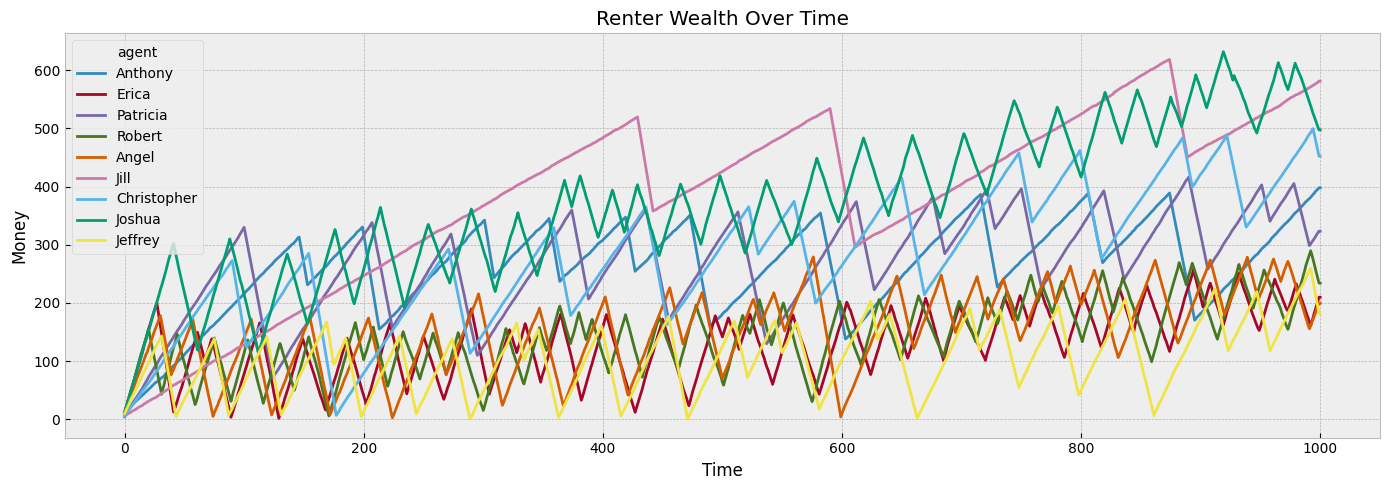

In [8]:
plot_renter_wealth(renter_wealth_gold)
plt.show()

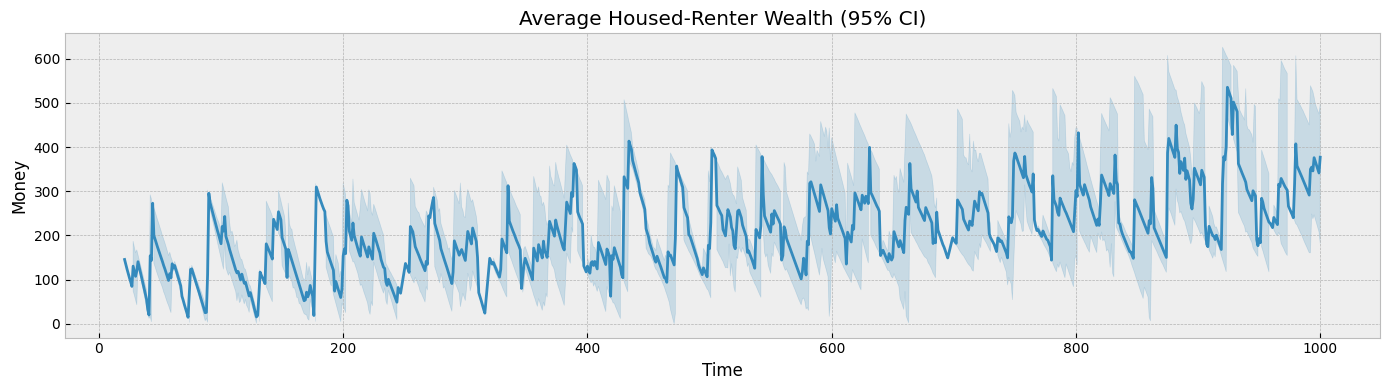

In [9]:
plot_housed_renter_wealth(housed_renter_wealth_gold)
plt.show()

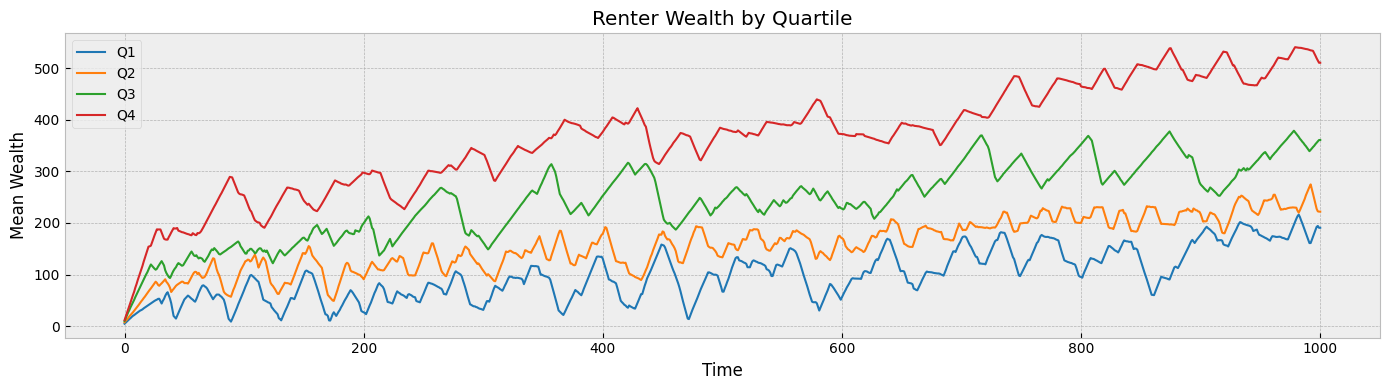

In [10]:
plot_wealth_quartiles(wealth_quartiles_gold)
plt.show()

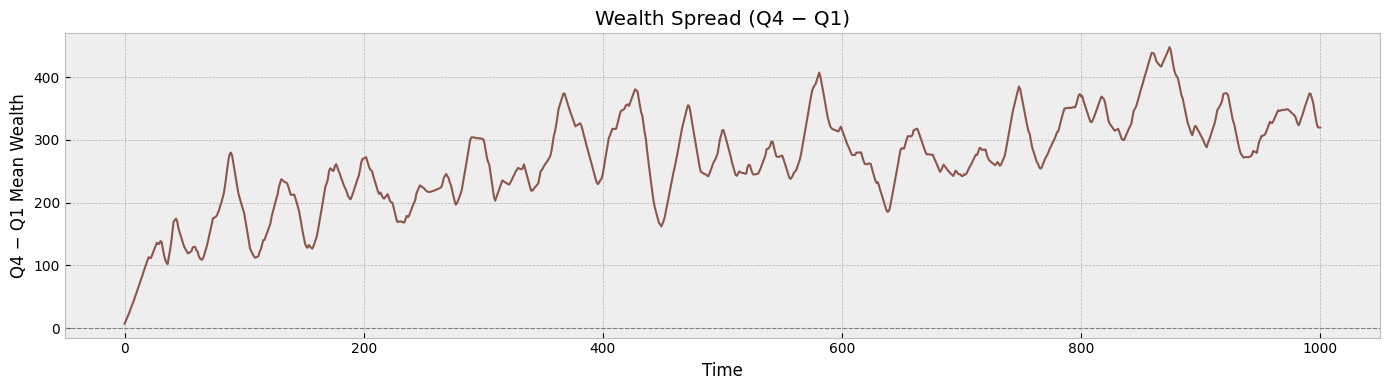

In [11]:
plot_wealth_spread(wealth_quartiles_gold)
plt.show()

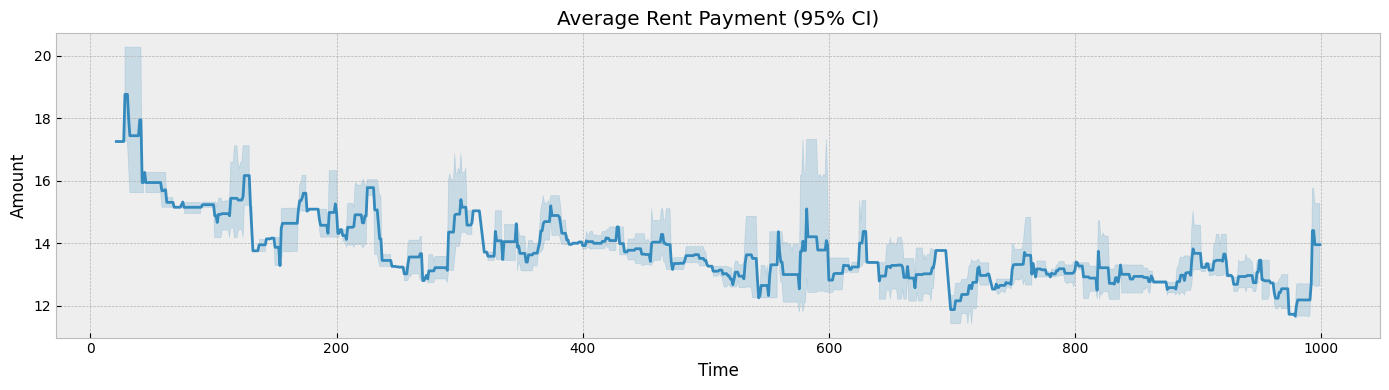

In [12]:
plot_avg_rent(rent_payments_gold)
plt.show()

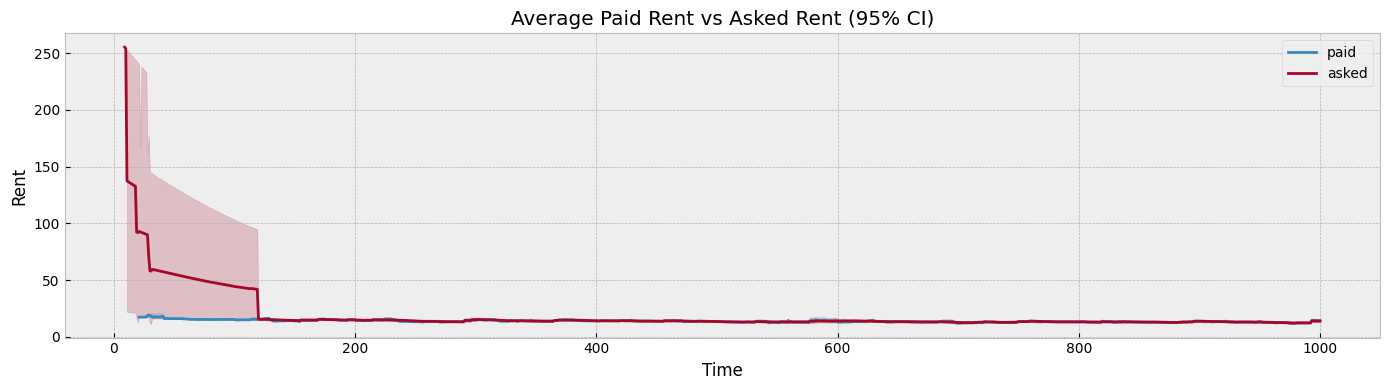

In [13]:
plot_paid_vs_asked(rent_comparison_gold)
plt.show()

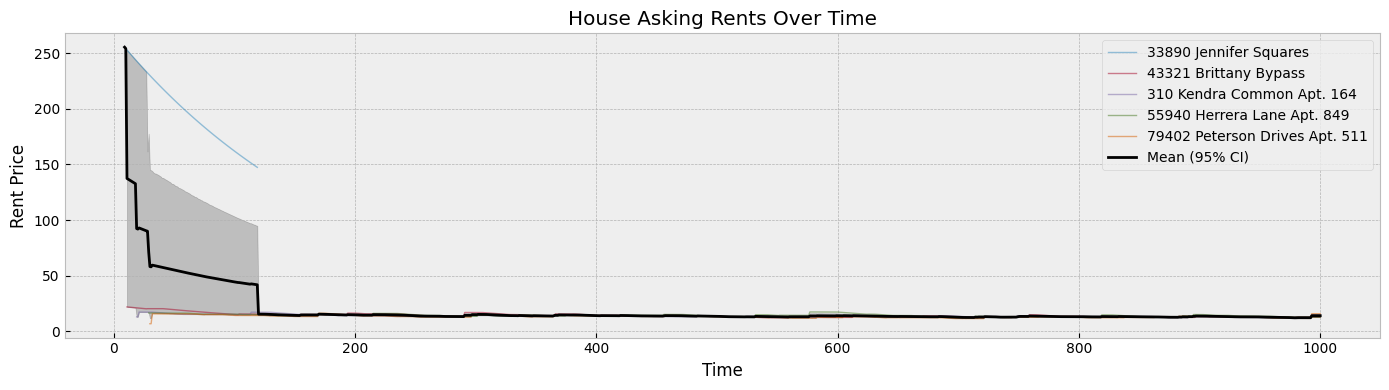

In [14]:
plot_house_rents(house_rents_gold)
plt.show()

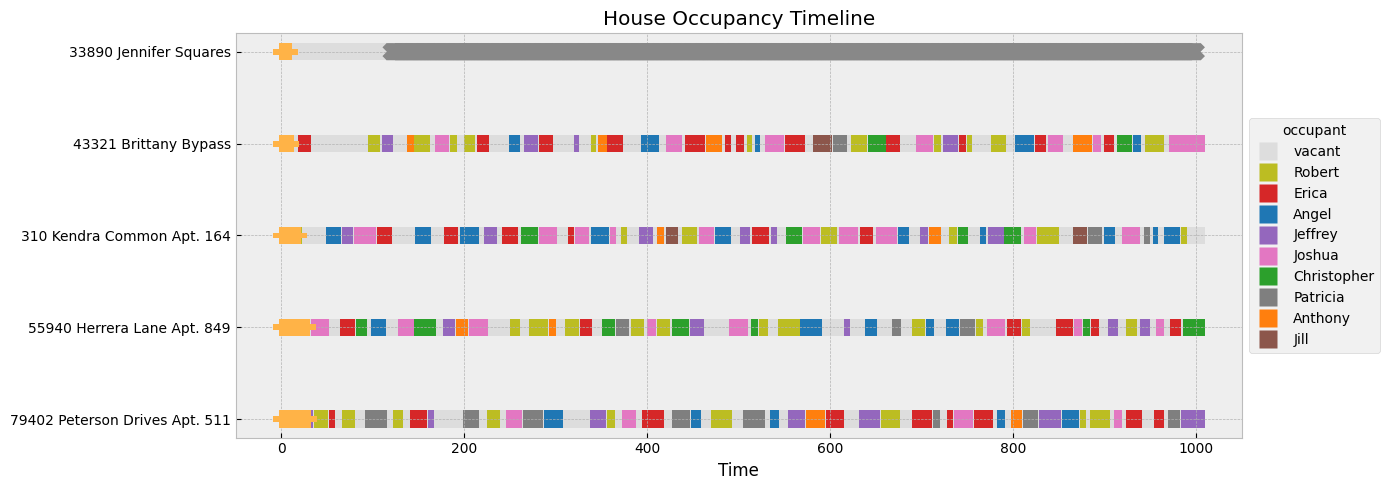

In [15]:
plot_occupancy(occupancy_timeline_gold)
plt.show()

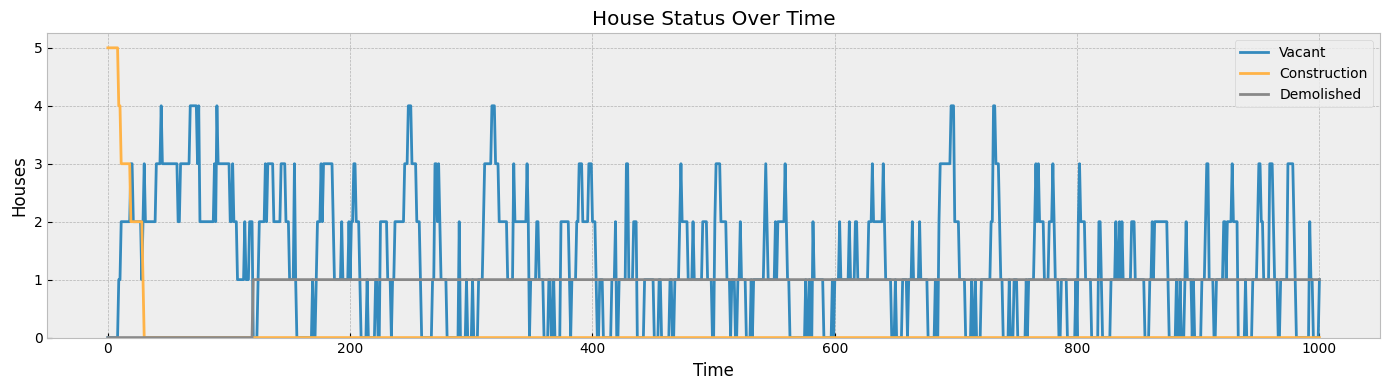

In [16]:
plot_vacancy(vacancy_count_gold)
plt.show()

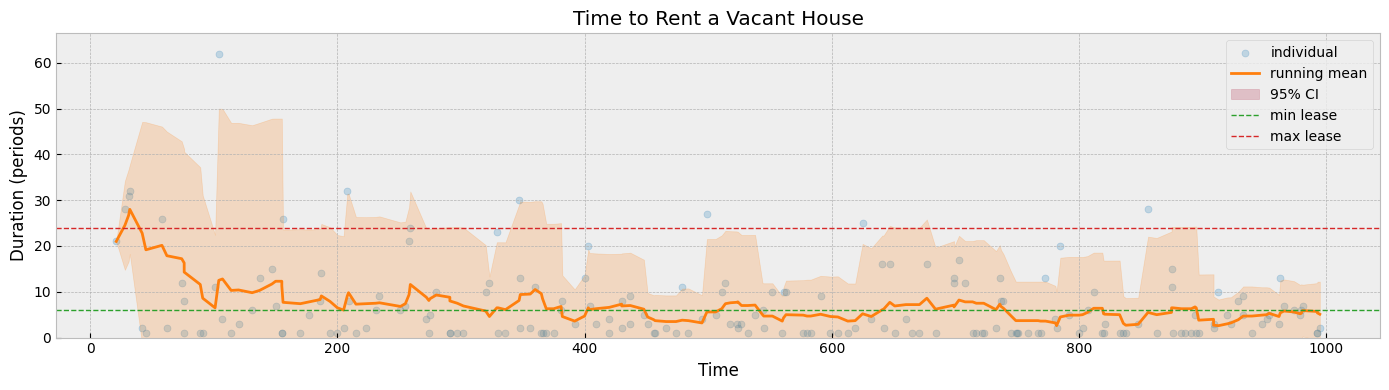

In [17]:
plot_time_to_rent(time_to_rent_rolling_gold, settings=settings)
plt.show()

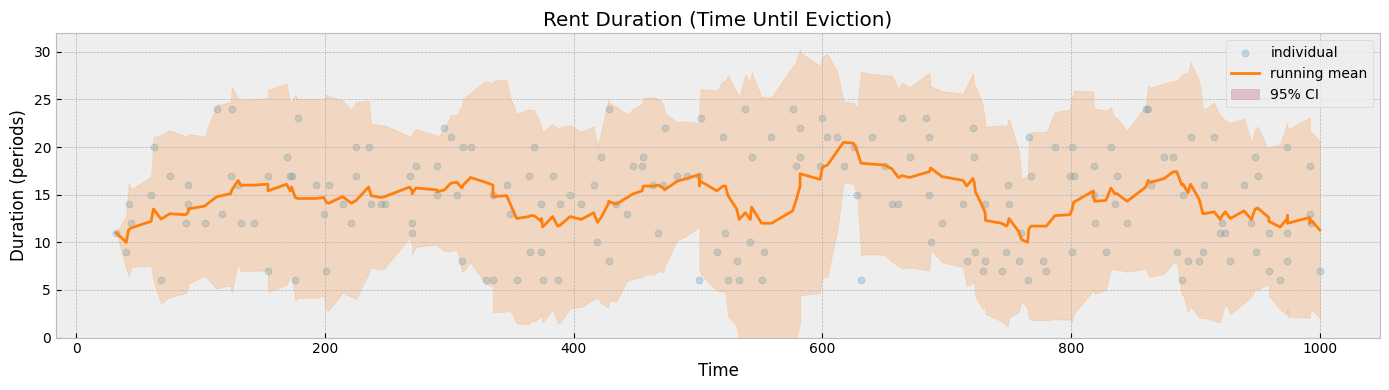

In [18]:
plot_rent_duration(rent_duration_rolling_gold)
plt.show()